In [1]:
#impor libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib
matplotlib.rcParams["figure.figsize"] = (20,10)

In [2]:
#now lets read the csv that we are gng to use
df1 = pd.read_csv("Bengaluru_House_Data.csv")
df1.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
#when we run shape it shows number of rows and columns in our df
df1.shape

(13320, 9)

In [4]:
#now we r gng to examine the area type feature first
#we r gng to group and aggregate the area types, and find the count of each of this categories
df1.groupby('area_type')['area_type'].agg('count')

area_type
Built-up  Area          2418
Carpet  Area              87
Plot  Area              2025
Super built-up  Area    8790
Name: area_type, dtype: int64

In [5]:
#now to keep our model simple we are gng to drop certain columns which donot play role in our prediction
df2 = df1.drop(['area_type','society','balcony','availability'], axis = 'columns')
df2.shape #to get no of rows and columns

(13320, 5)

In [6]:
df2.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [7]:
#NOW LETS BEGIN DATA_CLEANING
#it starts with handling the NA values,this is done by
df2.isnull().sum()
#this gives the output as number na values present in each columns

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [8]:
#we can drop this rows since the number rows with na values very small compared to our dataset that is 13000+
#if ur not willing to drop inthis case we can fill it with median value in place of na
df3 = df2.dropna()
#now lets look if there is any null values
df3.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
dtype: int64

In [9]:
df3.shape

(13246, 5)

In [10]:
#now lets analyse the size feature some have BHK, some are like bedrooms so lets look the unique terms
df3['size'].unique() #here df3['size'] this creates a pd series and we use unique() func to get the unique values

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [11]:
#wkt both bhk and bedrooms are same so we create new column to avoid this confusion
#this done simply by df3['bhk'] this is the new col created based on the size column,thn we r gng to apply some function here we can take the string and tokenize it with space so we get only the numbers inorder to do it we r using python lambda function
df3['bhk'] = df3['size'].apply(lambda x : int(x.split(" ")[0])) #on spliting the string using space we get two tokens and we take the number only which is at 0
#but it will in str only so to convert it we use int

C:\Users\DINESH~1\AppData\Local\Temp/ipykernel_1964/2960492503.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['bhk'] = df3['size'].apply(lambda x : int(x.split(" ")[0])) #on spliting the string using space we get two tokens and we take the number only which is at 0


In [12]:
df3.head() #now our new col is created

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,51.00,2


In [13]:
#to find the unique valuse of bhk, this gives different values of bedrooms
df3['bhk'].unique()

array([ 2,  4,  3,  6,  1,  8,  7,  5, 11,  9, 27, 10, 19, 16, 43, 14, 12,
       13, 18], dtype=int64)

In [14]:
#lets look into the unimaginable conditions
df3[df3.bhk>20] #since it is very rare to have 20 bhks in banglore

,location,size,total_sqft,bath,price,bhk
1718,2Electronic City Phase II,27 BHK,8000,27.0,230.0,27
4684,Munnekollal,43 Bedroom,2400,40.0,660.0,43


In [15]:
#we get two conditions but this seems be erroe since in 2000 sqft we cant have 43 bhk, before that lets analyze the sqft
df3.total_sqft.unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [16]:
#so we get sqft in range sometimes so we need to conveert it into single value by avg of the num and some in other units so we have to rectify it 
#inorder to do so we are creating a function isfloat
def is_float(x):
    try:
        float(x) #we r going to convert the value in sqft col to float if it is different we move to expect block
    except:
        return False
    return True

In [17]:
#now we gonna apply this func to df3 totalsqft col
df3[~df3['total_sqft'].apply(is_float)].head(10) #on simply without ~ it will return true but we need values so we put ~ operator this will return a df back
#so to fins so unique cases we can also apply head

,location,size,total_sqft,bath,price,bhk
30,Yelahanka,4 BHK,2100 - 2850,4.0,186.000,4
122,Hebbal,4 BHK,3067 - 8156,4.0,477.000,4
137,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,54.005,2
165,Sarjapur,2 BHK,1145 - 1340,2.0,43.490,2
188,KR Puram,2 BHK,1015 - 1540,2.0,56.800,2
410,Kengeri,1 BHK,34.46Sq. Meter,1.0,18.500,1
549,Hennur Road,2 BHK,1195 - 1440,2.0,63.770,2
648,Arekere,9 Bedroom,4125Perch,9.0,265.000,9
661,Yelahanka,2 BHK,1120 - 1145,2.0,48.130,2
672,Bettahalsoor,4 Bedroom,3090 - 5002,4.0,445.000,4


In [18]:
#now if we see they are in range, sqmetre,perch etc... so now to solve this anytime the value is in range we take avg if it is in other form we ingnore that rows
#so we write func to do so
def convert_sqft_to_num(x):
    tokens = x.split('-')
    if len(tokens) == 2:
        return(float(tokens[0])+float(tokens[1]))/2
    try:
        return float(x)
    except:
        return None

In [19]:
print(convert_sqft_to_num('2100 - 2850'))
print(convert_sqft_to_num('4125Perch'))
convert_sqft_to_num('2345')
#examples to check our function

2475.0
None


2345.0

In [20]:
#now we apply this func to our total_sqft col and creaate a new dataframe
df4 = df3.copy() #it is a copy of df3
#we perform on this df
df4['total_sqft'] = df4['total_sqft'].apply(convert_sqft_to_num) #now on this df we are gng to apply our function

In [21]:
#now lets look into it
df4.head()

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3
4,Kothanur,2 BHK,1200.0,2.0,51.00,2


In [22]:
#we can access the particular element using loc
df4.loc[410]

location      Kengeri
size            1 BHK
total_sqft        NaN
bath              1.0
price            18.5
bhk                 1
Name: 410, dtype: object

In [23]:
#we are gng to copy the df
df5 = df4.copy()

In [24]:
#now we r going to create price per sqft col which is necesary, this is kind of feature eng since we create a new feature from existing ones
df5['price_per_sqft'] = df5['price']*100000/df5['total_sqft'] #since our price is in lakhs
df5.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000


In [25]:
#now lets explore location column, it is categorical .
len(df5.location.unique())
#lets find its count

1304

In [26]:
#1304 categories is too much this kind of feature is called dimensionality curse which cause high dimensionality problem
#we have many techniques to avoid
#one such technique is adding other that is grouping the locations which has less datapoints
df5.location = df5.location.apply(lambda x : x.strip()) #this is done to remove some extra spaces like that to make it clean before proceeding
# lets create a var to count the data points in each location
location_stats = df5.groupby('location')['location'].agg('count')
location_stats
# now lets sort it
location_stats.sort_values(ascending=False)

location
Whitefield               535
Sarjapur  Road           392
Electronic City          304
Kanakpura Road           266
Thanisandra              236
                        ... 
1 Giri Nagar               1
Kanakapura Road,           1
Kanakapura main  Road      1
Karnataka Shabarimala      1
whitefiled                 1
Name: location, Length: 1293, dtype: int64

In [27]:
#so now inorder to reduce more we put data points less than 10 into others col
len(location_stats[location_stats<=10]) #to find how many have less than 10

1052

In [28]:
#now we r gng to make them as other\
location_stats_less_than_10 = location_stats[location_stats<=10]
location_stats_less_than_10

location
1 Annasandrapalya                                  1
1 Giri Nagar                                       1
1 Immadihalli                                      1
1 Ramamurthy Nagar                                 1
12th cross srinivas nagar banshankari 3rd stage    1
                                                  ..
t.c palya                                          1
tc.palya                                           4
vinayakanagar                                      1
white field,kadugodi                               1
whitefiled                                         1
Name: location, Length: 1052, dtype: int64

In [29]:
#now we r gng to put all them as others
len(df5.location.unique())

1293

In [30]:
df5.location = df5.location.apply(lambda x: 'other' if x in location_stats_less_than_10 else x) #all the locations with less than 10 will go to others
len(df5.location.unique())

242

In [31]:
df5.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000


In [32]:
#now we will look into outlier detection and removal these are data errors or represent extreme variation in data set so it is better to remove them else may create some issue
#this could be done by stanndard deviation or basic domain knowledge like when we have 2bhk apartment it cant be 500sqft, so if we ask any realestate owner they say the threshold per bedroom if 300sqft
#so now we print the above condition
df5[df5.total_sqft/df5.bhk < 300].head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
9,other,6 Bedroom,1020.0,6.0,370.0,6,36274.509804
45,HSR Layout,8 Bedroom,600.0,9.0,200.0,8,33333.333333
58,Murugeshpalya,6 Bedroom,1407.0,4.0,150.0,6,10660.980810
68,Devarachikkanahalli,8 Bedroom,1350.0,7.0,85.0,8,6296.296296
70,other,3 Bedroom,500.0,3.0,100.0,3,20000.000000


In [33]:
#so above results are unusual on using this in our model may affect the predictions so we have to remove them
#we use negatte (~) in order to filter
df6 = df5[~(df5.total_sqft/df5.bhk < 300)]
df6.shape #now we have removed some  outlier

(12502, 7)

In [34]:
#now lwts look into price_per_sqft , so we first look into it
df6.price_per_sqft.describe()

count     12456.000000
mean       6308.502826
std        4168.127339
min         267.829813
25%        4210.526316
50%        5294.117647
75%        6916.666667
max      176470.588235
Name: price_per_sqft, dtype: float64

In [35]:
#in banglore it is not possible to get persqft at 267 and since we r building a generic model it is also not possible to have 176470 per sqft
#so we r gng to write a func that is gng to filter this based on sd, acc to this theory most of the data points(app ~ 68%) should lie between mean and 1 sd, so we r gng to filter out anyhting beyond 1sd
#so we have to do it for per location and find mean 
def remove_pps_outliers(df):#here we ip the dataframe df 
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'): #then grouping them by location this we take as subdf and for this we r calc mean and std
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        reduced_df = subdf[(subdf.price_per_sqft > (m-st)) & (subdf.price_per_sqft <= (m+st))] #so here we r filtering by anything above m-st(mean - 1 std) and anything below m+std we will keep it and we keep on appending it in our dfout dataframe        df_out = pd.concat([df_out,reduced_df],ignore_index = True)
        df_out = pd.concat([df_out,reduced_df],ignore_index = True)
    return df_out
df7 = remove_pps_outliers(df6)
df7.shape #so we removed around 2000 outliers

(10241, 7)

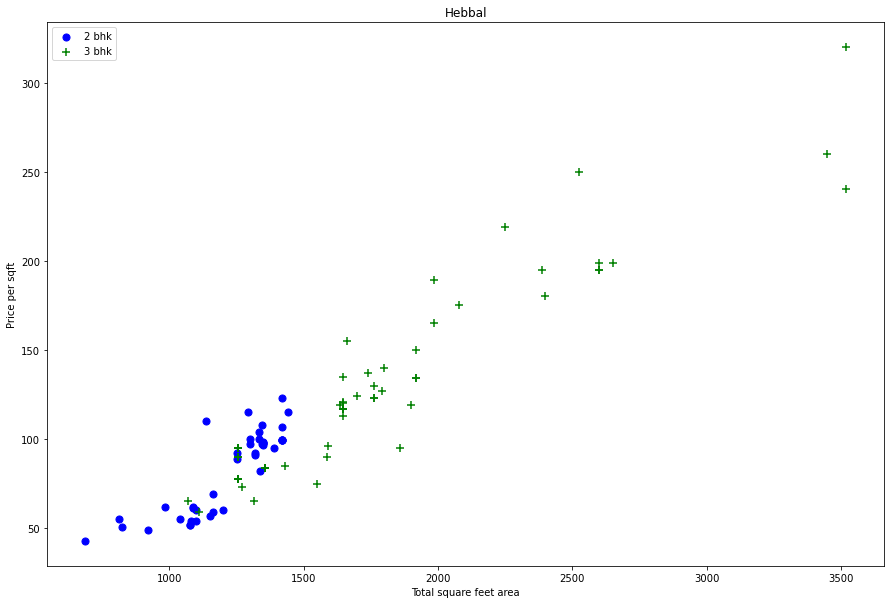

In [36]:
#so in our dataset some cases with same sqft but 3bhk is lower price compared to 2bhk so we now visualize these conditions
def plot_scatter_chart(df,location):
    bhk2 = df[(df.location == location)&(df.bhk==2)] #this is to create two different df for 2bhk and 3bhk but for same location
    bhk3 = df[(df.location == location)&(df.bhk==3)]
    matplotlib.rcParams['figure.figsize'] = (15,10)
    plt.scatter(bhk2.total_sqft,bhk2.price,color='blue',label = '2 bhk', s=50) #this two lines are used for scatterplot plotting
    plt.scatter(bhk3.total_sqft,bhk3.price,marker = '+',color='green',label = '3 bhk', s=50)
    plt.xlabel("Total square feet area")
    plt.ylabel("Price per sqft")
    plt.title(location)
    plt.legend()
#this func takes df and location as input and plot the respective plots,and it plots scatter plot for 2bhk and 3 bhk appartments,x-axis have total area and y-axis have pps
plot_scatter_chart(df7,"Hebbal")

In [37]:
#from above plot we could observe that in same are for same sqft 2bhk price is higher than 3bhk this ia error so we have to remove this kind of data
#so in many cases we have this kind of outliers so we have to clean it
#now first we are gng to take a location and categorize it acc to diff bhk if for same location 2bhk price is less than 1 bhk then we are gng to remove that outlier throughout the df

In [38]:
def remove_bhk_outliers(df):
    exclude_indices = np.array([]) #we r creating an empty numpy array
    for location, location_df in df.groupby('location'): #here we r creating a neew df from location groupby
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bhk'): #here we r creating a new df from bhk groupby
            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df.price_per_sqft),
                'std': np.std(bhk_df.price_per_sqft),
                'count': bhk_df.shape[0]
            } #this above four lines helps in creating the dictionary with mean,std,count of diff bhk
        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk-1) #here again we r creating the df
            if stats and stats['count']>5:  #we include conditions if stats count is greater than 5 only we have to proceed
                exclude_indices = np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft<(stats['mean'])].index.values)  #we append the points which are outliers in this np array
    return df.drop(exclude_indices,axis='index') #then we drop this np array from our df
df8 = remove_bhk_outliers(df7)
# df8 = df7.copy()
df8.shape #now it removed many outliers

(7329, 7)

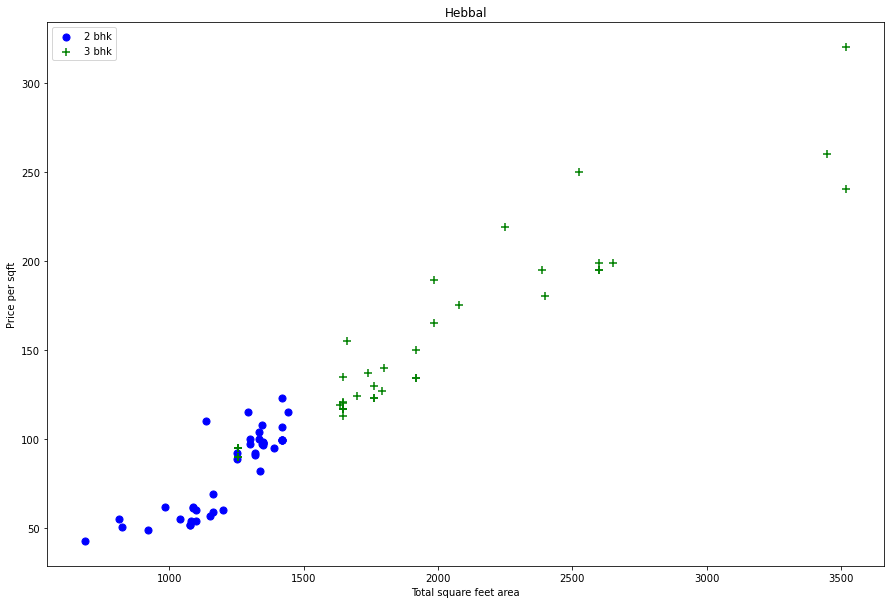

In [39]:
#now lets check again by plotting the same
plot_scatter_chart(df8,"Hebbal")
#now if we see majority of outliers has been removed

Text(0, 0.5, 'count')

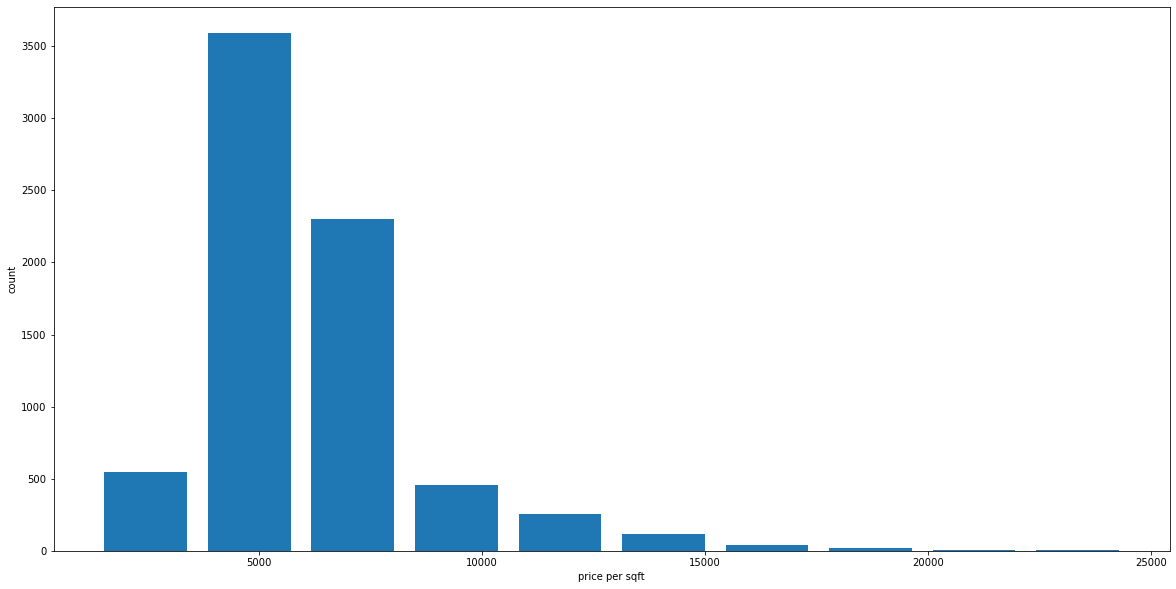

In [40]:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (20,10)
plt.hist(df8.price_per_sqft,rwidth = 0.8) #rwidth is width of the bar
plt.xlabel("price per sqft")
plt.ylabel("count")
#by this plot we plot number of properties in particular range of sqft

In [41]:
#now lets look into bathroom feature
df8.bath.unique() #these gives count of each number of bathrooms

array([ 4.,  3.,  2.,  5.,  8.,  1.,  6.,  7.,  9., 12., 16., 13.])

In [42]:
#now lets check and remove the number of bath more than 10
df8[df8.bath>10]
#we have only 5 datapoints
#by basic domain know., for a 2bhk we have 2 bathrooms so for 2 bhk we dont have 4 bathrooms so this is unusual

,location,size,total_sqft,bath,price,bhk,price_per_sqft
5277,Neeladri Nagar,10 BHK,4000.0,12.0,160.0,10,4000.000000
8486,other,10 BHK,12000.0,12.0,525.0,10,4375.000000
8575,other,16 BHK,10000.0,16.0,550.0,16,5500.000000
9308,other,11 BHK,6000.0,12.0,150.0,11,2500.000000
9639,other,13 BHK,5425.0,13.0,275.0,13,5069.124424


Text(0, 0.5, 'count')

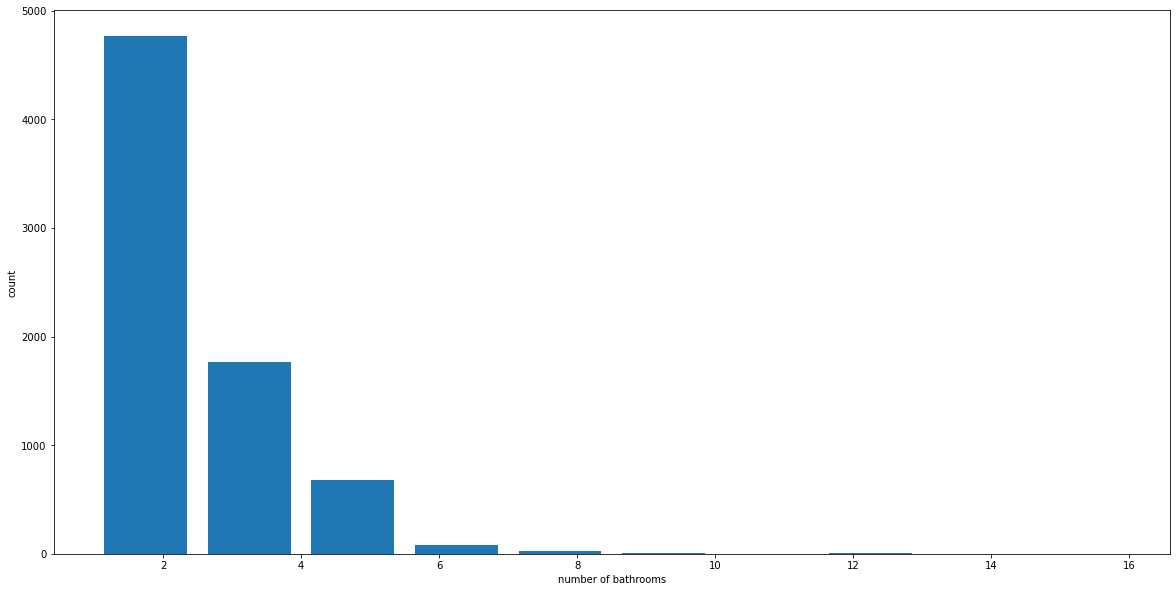

In [43]:
#now lets again plot num of bathrooms vs count
plt.hist(df8.bath,rwidth = 0.8)
plt.xlabel('number of bathrooms')
plt.ylabel('count')
#most of the properties have 2 bathrooms

In [44]:
#so we remove bathroom outliers
df8[df8.bath>df8.bhk+2] #that is whenever we have bathrooms more than bhk+2 we call it as outlier and remove it

,location,size,total_sqft,bath,price,bhk,price_per_sqft
1626,Chikkabanavar,4 Bedroom,2460.0,7.0,80.0,4,3252.032520
5238,Nagasandra,4 Bedroom,7000.0,8.0,450.0,4,6428.571429
6711,Thanisandra,3 BHK,1806.0,6.0,116.0,3,6423.034330
8411,other,6 BHK,11338.0,9.0,1000.0,6,8819.897689


In [45]:
df9 = df8[df8.bath<df8.bhk+2] #we removed the above outliers
df9.shape

(7251, 7)

In [46]:
#SO NOW OUR DATASET IS MUCH MORE CLEANER SO WE CAN USE IT FOR ML PREPARATION
#before it we drop unwanted features from our dataset
#like size and pricepersqft we used this only for outlier removal and has no other use in prediction
df10 = df9.drop(['size','price_per_sqft'],axis='columns')
df10.head()

,location,total_sqft,bath,price,bhk
0,1st Block Jayanagar,2850.0,4.0,428.0,4
1,1st Block Jayanagar,1630.0,3.0,194.0,3
2,1st Block Jayanagar,1875.0,2.0,235.0,3
3,1st Block Jayanagar,1200.0,2.0,130.0,3
4,1st Block Jayanagar,1235.0,2.0,148.0,2


In [47]:
#NOW WE R GNG TO BUILD ML MODEL AND COME UP WITH ALGORITHM
#we know that ml model cannot interpret text data so we have to convert it into numeric column
#noe of the ways of converting it is one-hot-encoding also called dummies so we r gng to use pandas dummies method here
dummies = pd.get_dummies(df10.location)
dummies.head()
#on running it for each of the location it will create a new column for that location the value is set to 1 and remaining places it is 0

,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,9th Phase JP Nagar,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,other
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [48]:
#now lets append it inour df,so we create new df called df11
df11 = pd.concat([df10,dummies.drop('other',axis='columns')],axis='columns') #to avoid the concept of dummy variable trap we should have onedummies column so we drop the last column
df11.head()

,location,total_sqft,bath,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,1st Block Jayanagar,2850.0,4.0,428.0,4,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1st Block Jayanagar,1630.0,3.0,194.0,3,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1st Block Jayanagar,1875.0,2.0,235.0,3,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1st Block Jayanagar,1200.0,2.0,130.0,3,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1st Block Jayanagar,1235.0,2.0,148.0,2,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [49]:
#now we can also drop location column since we have created dummies column 
df12 = df11.drop('location',axis='columns')
df12.head()

,total_sqft,bath,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,2850.0,4.0,428.0,4,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1630.0,3.0,194.0,3,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1875.0,2.0,235.0,3,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1200.0,2.0,130.0,3,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1235.0,2.0,148.0,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [50]:
#this shows how our data pipelining became i.e df1 is one stage similarly df2....
df12.shape

(7251, 245)

In [51]:
#lets create a x variable which should contain only independent variable so we drop price
x = df12.drop('price',axis='columns')
x.head()
#this x is required for our model training which contains only independent variables

,total_sqft,bath,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,2850.0,4.0,4,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1630.0,3.0,3,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1875.0,2.0,3,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1200.0,2.0,3,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1235.0,2.0,2,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [52]:
y = df12.price #this var consists of dependent variables
y.head()

0    428.0
1    194.0
2    235.0
3    130.0
4    148.0
Name: price, dtype: float64

In [53]:
#now our dependent and independent variables are ready
#then we go to train-test split
#we use training data for model training and test data for evaluation
#we r gng to import traintest split method from sklearn
from sklearn.model_selection import train_test_split 
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state = 10) #our test size is 20%

In [54]:
#we r gng to create a linear regression model
from sklearn.linear_model import LinearRegression
lr_clf = LinearRegression()
lr_clf.fit(x_train,y_train) #fiting our data and training our model is done in this step
lr_clf.score(x_test,y_test) #this step evaluates score of our model

0.845227769787429

In [55]:
#we have to create different models inorder to come up with decent score so next lets create five-fold model(k-fold)
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state = 0) #this is nothing but we r shuffling or randomizing our data for cross validation

cross_val_score(LinearRegression(),x,y,cv=cv) #yields the respective crossvalidation scores
#so for our regression model we apply 5 fold cv we yield 80% above

array([0.82430186, 0.77166234, 0.85089567, 0.80837764, 0.83653286])

In [56]:
#how about trying few other regression techniques and find which one yields best result for this we use grid_search cv this ia api provided by sklearn which runs our model in different regressors and parameters and tells us which is best one
#now lets import it
from sklearn.model_selection import GridSearchCV
#we r gng to try lasso and decison tree regressor
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
#we write a func to find a best model

def find_best_model_using_gridsearchcv(x,y): #we give x and y as input and it should say which algorithm is best, in this we have algorithm and specified with parameters ,this is called hyperparameter tuning technique since italso gives the best parameter for our model
    algos = {
        'linear_regression' : {
            'model': LinearRegression(),
            'params': {
                'normalize': [True, False]
            }
        },
        'lasso': {
            'model': Lasso(),
            'params': {
                'alpha': [1,2],
                'selection': ['random', 'cyclic']
            }
        },
        'decision_tree': {
            'model': DecisionTreeRegressor(),
            'params': {
                'criterion' : ['mse','friedman_mse'],
                'splitter': ['best','random']
            }
        }
    }
    scores = [] #result of above func scores is stored in this list
    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0) #this is to randomize our data so that we could get more better result
    for algo_name, config in algos.items(): #we r gng through this py library 
        gs =  GridSearchCV(config['model'], config['params'], cv=cv, return_train_score=False) #initializing grid search cv with this model and parameters in algos above,cv object is used for cross validation 
        gs.fit(x,y) #we call this fit method training is done in this step
        scores.append({
            'model': algo_name,
            'best_score': gs.best_score_, #this shows the best score
            'best_params': gs.best_params_ #this shows the best parameter
        }) #then we append the corresponding score results of this training scores in this list

    return pd.DataFrame(scores,columns=['model','best_score','best_params']) #the resultant scores is returned in this dataframe

find_best_model_using_gridsearchcv(x,y) #we r calling now, this gives us the best model and best parameters

C:\Users\Dineshkumar\anaconda3\lib\site-packages\sklearn\linear_model\_base.py:141: FutureWarning: 'normalize' was deprecated in version 1.0 and will be removed in 1.2.
If you wish to scale the data, use Pipeline with a StandardScaler in a preprocessing stage. To reproduce the previous behavior:

from sklearn.pipeline import make_pipeline

model = make_pipeline(StandardScaler(with_mean=False), LinearRegression())

If you wish to pass a sample_weight parameter, you need to pass it as a fit parameter to each step of the pipeline as follows:

kwargs = {s[0] + '__sample_weight': sample_weight for s in model.steps}
model.fit(X, y, **kwargs)


  warnings.warn(
C:\Users\Dineshkumar\anaconda3\lib\site-packages\sklearn\linear_model\_base.py:141: FutureWarning: 'normalize' was deprecated in version 1.0 and will be removed in 1.2.
If you wish to scale the data, use Pipeline with a StandardScaler in a preprocessing stage. To reproduce the previous behavior:

from sklearn.pipeline import make_pipel

,model,best_score,best_params
0,linear_regression,0.818354,{'normalize': True}
1,lasso,0.687431,"{'alpha': 1, 'selection': 'random'}"
2,decision_tree,0.722265,"{'criterion': 'friedman_mse', 'splitter': 'ran..."


In [58]:
#now the winner is linear regression it has maximum score
#so now we use the already created lr_clf it is already with 84% score
#we predict using this model
def predict_price(location,sqft,bath,bhk):   #this will take location,sqft,bath,bhk as input and return estimated price 
    loc_index = np.where(x.columns==location)[0][0] #this gives location column index

    X = np.zeros(len(x.columns)) #in this array the first col is sqft,2nd is bath, 3rd is bhk
    X[0] = sqft
    X[1] = bath
    X[2] = bhk
    if loc_index >= 0: #for location we r using its index
        X[loc_index] = 1 #once we have location index we can set it to 1 this will give the predicted price

    return lr_clf.predict([X])[0]


In [59]:
predict_price('1st Phase JP Nagar',1000,2,2) #lets predict the price 

C:\Users\Dineshkumar\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


83.49904677172415

In [66]:
predict_price('1st Phase JP Nagar',1000,3,3)

C:\Users\Dineshkumar\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


86.80519395199

In [67]:
#now lets look for high price location
predict_price('Indira Nagar',1000,2,2)

C:\Users\Dineshkumar\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


181.27815484006965

In [69]:
#so is we takeup conditions with less bath and bhk sometimes price will be low this doesnt mean our model is wrong it is what our model tells us
#this can be due to some cases like where due to increase in bathroom the size of the rooms could belesslikewise

In [70]:
#so now its time to export our model to pickle file,this will be used by our python flask server
import pickle
with open('banglore_home_prices_model.pickle','wb') as f:
    pickle.dump(lr_clf,f)

In [72]:
#otherthan the model we also nee columns info which we have in our predict_price func,becoz the index is important for our model so we import it as json file
import json
columns={
    'data_columns' : [col.lower() for col in x.columns] #all the columns we r converting into lowercase
}
with open("columns.json","w") as f:
    f.write(json.dumps(columns)) #dumping all into json file